In [1]:
import numpy as np
import pandas as pd

class Connect4:

    def __init__(self):
        self.height = 6
        self.width = 7
        self.board_state = np.zeros([self.height, self.width], dtype=np.int8)
        self.players = {1: 1, 2: 2}
        self.gameOver = False
        self.reward = {'win': 1, 'draw': 0.5, 'lose': -1}

    def make_move(self, m, player):
        # check if move is valid
        if m in self.get_allowed_moves():
            # get idx of the first open slow from the bottom of the column 
            col = self.board_state[:, m]
            # if col = [0, 0, 0, 1, 2, 1], (col != 0) = [False, False, False, True, True, True], 
            # argmax of this finds the first True which is idx 3, so open slot from top is 2
            open_slot = np.argmax(col != 0) - 1
            self.board_state[open_slot, m] = self.players[player]
        else:
            print('Move is not allowed!')
            print(f"Trying to play move {m}, allowed moves = {self.get_allowed_moves()}")
            self.render()

        reward = self.check_game_done(player)
        
        # give feedback as new state and reward
        return self.board_state.copy(), reward
        
    def get_allowed_moves(self):
        available_cols = []
        for j in range(self.width):
            col = self.board_state[:, j]
            if 0 in col:
                available_cols.append(j)
        return available_cols

    def checkHas4InARow(self, arr, player):
        # This checks if a list has 4 in a row of the player's pieces. 
        # It iterates through the list once, keeping track of the current 
        # value and count, and updates the longest count and value when it 
        # encounters a different value. Finally, it checks if the longest 
        # value is the player's piece and if the longest count is at least 4.
        # (more efficienct as only iterates through the list once, instead of checking for each possible 4 in a row)

        current_val = arr[0]
        current_count = 1

        longest_val = arr[0]
        longest_count = 1

        for val in arr[1:]:
            if val == current_val:
                current_count += 1
            else:
                current_val = val
                current_count = 1
            
            if current_count > longest_count:
                longest_count = current_count
                longest_val = current_val
        
        if (longest_val == player) and (longest_count >= 4):
            return True

        return False
        
    def check_game_done(self, player):

        # check if it is a draw first, as if it is a draw then there is no need to check for 4 in a row
        if np.sum(self.board_state == 0) == 0:
            self.gameOver = True
            return self.reward['draw']
        
        # if not a draw, check if there is 4 in a row for the player
        # check if 4 consecutive 1s or 2s
        for i in range(self.width):
            col = self.board_state[:,i]
            has4 = self.checkHas4InARow(col, player)
            if has4:
                self.gameOver = True

        # now check the rows 
        for i in range(self.height):
            row = self.board_state[i,:]
            has4 = self.checkHas4InARow(row, player)
            if has4:
                self.gameOver = True

        # now check the diagonals
        # Start with right diagonals, so start from the bottom left corner and move up to the right 
        # The starting points are given by the x's shown below:
        #   - - - - - - -
        #   - - - - - - -
        #   - - - - - - -
        #   x x x - - - -
        #   x x x - - - -
        #   x x x - - - -
        for col_idx in range(0, 4):
            for row_idx in range(3, 6):
                right_diagonal = [self.board_state[row_idx - d, col_idx + d] for d in range(4)]
                has4 = self.checkHas4InARow(right_diagonal, player)
                if has4:
                    self.gameOver = True
        # Now do left diagonals
        # The starting points are given by the x's shown below:
        #   - - - - - - -
        #   - - - - - - -
        #   - - - - - - -
        #   - - - - x x x
        #   - - - - x x x
        #   - - - - x x x
        for col_idx in range(3, 7):
            for row_idx in range(3, 6):
                left_diagonal = [self.board_state[row_idx - d, col_idx - d] for d in range(4)]
                has4 = self.checkHas4InARow(left_diagonal, player)
                if has4:
                    self.gameOver = True

        if self.gameOver:
            return self.reward['win']
        else:
            return 0.
        

    def render(self):
        rendered_board_state = self.board_state.copy().astype(np.str)
        rendered_board_state[self.board_state == 0] = ' '
        rendered_board_state[self.board_state == 1] = 'O'
        rendered_board_state[self.board_state == 2] = 'X'
        display(pd.DataFrame(rendered_board_state))
    
    def reset(self):
        self.__init__()

board = Connect4()

In [35]:
from collections import deque
import random
from dataclasses import dataclass

@dataclass
class Transition:
    state:      object   # e.g. np.ndarray (N,M)
    action:     int
    reward:     float
    next_state: object   # np.ndarray or None
    done:       bool

class ReplayBuffer:
    def __init__(self, capacity: int):
        self.memory = deque(maxlen=capacity)

    def add(self, tr: Transition):
        self.memory.append(tr)

    def sample(self, batch_size: int):
        return random.sample(self.memory, batch_size)

    def __len__(self):
        return len(self.memory)
    
replay_buffer = ReplayBuffer(100_000)

In [36]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class DQN(nn.Module):
    
    def __init__(self, outputs):
        super(DQN, self).__init__()
        # 6 by 7, 10 by 11 
        self.conv1 = nn.Conv2d(1, 32, kernel_size=5, padding=2)
        self.conv2 = nn.Conv2d(32, 32, kernel_size=5, padding=2)
        self.conv3 = nn.Conv2d(32, 32, kernel_size=5, padding=2)
        self.conv4 = nn.Conv2d(32, 32, kernel_size=5, padding=2)
        self.conv5 = nn.Conv2d(32, 32, kernel_size=5, padding=2)
        self.conv6 = nn.Conv2d(32, 32, kernel_size=5, padding=2)
        self.conv7 = nn.Conv2d(32, 32, kernel_size=5, padding=2)

        linear_input_size = 6 * 7 * 32
        self.MLP1 = nn.Linear(linear_input_size, 50)
        self.MLP2 = nn.Linear(50, 50)
        self.MLP3 = nn.Linear(50, 50)
        self.MLP4 = nn.Linear(50, outputs)
        
    def forward(self, x):
        x = F.leaky_relu(self.conv1(x))
        x = F.leaky_relu(self.conv2(x))
        x = F.leaky_relu(self.conv3(x))
        x = F.leaky_relu(self.conv4(x))
        x = F.leaky_relu(self.conv5(x))
        x = F.leaky_relu(self.conv6(x))
        x = F.leaky_relu(self.conv7(x))
        # flatten the feature vector except batch dimension
        x = x.view(x.size(0), -1)
        x = F.leaky_relu(self.MLP1(x))
        x = F.leaky_relu(self.MLP2(x))
        x = F.leaky_relu(self.MLP3(x))
        return self.MLP4(x)

/home/emc21/miniconda3/envs/GNN_Env/lib/python3.9/site-packages/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [37]:
import math
from typing import Optional, Tuple

import torch
import torch.nn as nn
import torch.nn.functional as F


class MultiHeadAttention(nn.Module):
    def __init__(self, d_model: int, num_heads: int):
        super(MultiHeadAttention, self).__init__()
        assert d_model % num_heads == 0, "d_model must be divisible by num_heads"

        self.d_model = d_model
        self.num_heads = num_heads
        self.d_k = d_model // num_heads

        self.W_q = nn.Linear(d_model, d_model)
        self.W_k = nn.Linear(d_model, d_model)
        self.W_v = nn.Linear(d_model, d_model)
        self.W_o = nn.Linear(d_model, d_model)

    def scaled_dot_product_attention(self, Q, K, V, mask=None):
        # Q,K,V: (B, H, S, d_k)
        attn_scores = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(self.d_k)  # (B,H,S,S)

        # mask should broadcast to (B,H,S,S). Common for key masking: (B,1,1,S)
        if mask is not None:
            attn_scores = attn_scores.masked_fill(mask == 0, -1e9)

        attn_probs = torch.softmax(attn_scores, dim=-1)
        output = torch.matmul(attn_probs, V)  # (B,H,S,d_k)
        return output

    def split_heads(self, x):
        # x: (B, S, d_model) -> (B, H, S, d_k)
        batch_size, seq_length, _ = x.size()
        return x.view(batch_size, seq_length, self.num_heads, self.d_k).transpose(1, 2)

    def combine_heads(self, x):
        # x: (B, H, S, d_k) -> (B, S, d_model)
        batch_size, _, seq_length, _ = x.size()
        return x.transpose(1, 2).contiguous().view(batch_size, seq_length, self.d_model)

    def forward(self, Q, K, V, mask=None):
        Q = self.split_heads(self.W_q(Q))
        K = self.split_heads(self.W_k(K))
        V = self.split_heads(self.W_v(V))

        attn_output = self.scaled_dot_product_attention(Q, K, V, mask)
        output = self.W_o(self.combine_heads(attn_output))  # (B,S,d_model)
        return output


class TransformerEncoderLayer(nn.Module):
    """
    Pre-LN Transformer encoder block:
      x = x + MHA(LN(x))
      x = x + FFN(LN(x))
    """
    def __init__(self, d_model: int, num_heads: int, d_ff: int, dropout: float = 0.1):
        super().__init__()
        self.ln1 = nn.LayerNorm(d_model)
        self.ln2 = nn.LayerNorm(d_model)

        self.mha = MultiHeadAttention(d_model, num_heads)

        self.ffn = nn.Sequential(
            nn.Linear(d_model, d_ff),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(d_ff, d_model),
        )

        self.dropout = nn.Dropout(dropout)

    def forward(self, x: torch.Tensor, attn_mask: Optional[torch.Tensor] = None) -> torch.Tensor:
        x = x + self.dropout(self.mha(self.ln1(x), self.ln1(x), self.ln1(x), attn_mask))
        x = x + self.dropout(self.ffn(self.ln2(x)))
        return x


class TransformerDQN(nn.Module):
    """
    Connect-k policy network that selects a COLUMN action.

    Required inputs:
      board: LongTensor (B, N, M) with values {0,1,2}
        0 = empty, 1 = player1 piece, 2 = player2 piece

      player_to_move: LongTensor (B,) with values {0,1}
        0 = player1 to move, 1 = player2 to move

    Outputs:
      logits:        (B, M) raw logits over columns (unmasked)
      masked_logits: (B, M) logits with invalid columns set to -1e9 (safe for softmax/CE)
      valid_mask:    (B, M) boolean; True means column is playable (not full)
    """
    def __init__(
        self,
        d_model: int = 64,
        num_heads: int = 4,
        num_layers: int = 4,
        d_ff: int = 128,
        dropout: float = 0,
    ):
        super().__init__()
        self.n_rows = 6
        self.n_cols = 7
        self.seq_len = self.n_rows * self.n_cols
        self.d_model = d_model

        # Categorical embedding for cell states {0,1,2}
        self.cell_embed = nn.Embedding(3, d_model)

        # 2D learned positional embeddings (row + col)
        self.row_embed = nn.Embedding(self.n_rows, d_model)
        self.col_embed = nn.Embedding(self.n_cols, d_model)

        # CLS token is ALWAYS used
        self.cls = nn.Parameter(torch.zeros(1, 1, d_model))
        nn.init.normal_(self.cls, std=0.02)

        self.layers = nn.ModuleList(
            [TransformerEncoderLayer(d_model, num_heads, d_ff, dropout) for _ in range(num_layers)]
        )
        self.final_ln = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)

        # Policy head: one logit per column action (0..M-1)
        self.policy_head = nn.Linear(d_model, self.n_cols)

    @staticmethod
    def compute_valid_action_mask(board: torch.Tensor) -> torch.Tensor:
        """
        A column is valid if its TOP cell is empty (gravity connect-style).
        Assumes row index 0 is the TOP row, as in your examples.

        board: (B,N,M) values {0,1,2}
        returns: (B,M) bool
        """
        top_row = board[:, 0, :]  # (B,M)
        return top_row == 0

    def forward(
        self,
        board: torch.Tensor,
        valid_action_mask: Optional[torch.Tensor] = None,
    ) -> Tuple[torch.Tensor, torch.Tensor, torch.Tensor]:

        B, N, M = board.shape

        # 1) Embed cells: (B,N,M,d_model)
        x = self.cell_embed(board)

        # 2) Add 2D positional embeddings
        rows = torch.arange(self.n_rows, device=board.device).unsqueeze(1).expand(self.n_rows, self.n_cols)
        cols = torch.arange(self.n_cols, device=board.device).unsqueeze(0).expand(self.n_rows, self.n_cols)
        pos = self.row_embed(rows) + self.col_embed(cols)     # (N,M,d_model)
        x = x + pos.unsqueeze(0)                              # (B,N,M,d_model)

        # 3) Flatten to sequence: (B, S, d_model)
        x = x.view(B, self.seq_len, self.d_model)

        # 4) Prepend CLS: (B, 1+S, d_model)
        cls = self.cls.expand(B, -1, -1)
        x = torch.cat([cls, x], dim=1)
        x = self.dropout(x) #! maybe do the dropout before prepending?

        # 5) Encoder stack
        for layer in self.layers:
            x = layer(x)

        x = self.final_ln(x)

        # 6) Readout from CLS
        h = x[:, 0, :]  # (B,d_model)

        # 7) Column logits
        logits = self.policy_head(h)  # (B,M)

        # 8) Valid action masking
        if valid_action_mask is None:
            valid_action_mask = self.compute_valid_action_mask(board)  # (B,M) bool
        else:
            valid_action_mask = valid_action_mask.bool()

        masked_logits = logits.masked_fill(~valid_action_mask, -1e9)

        return logits, masked_logits, valid_action_mask


# -----------------------
# Example usage
# -----------------------
if __name__ == "__main__":
    # Example board
    board_example = torch.zeros(6, 7, dtype=torch.long).unsqueeze(0)  # (B=1, N=6, M=7)
    print(board_example)

    model = TransformerDQN(
        d_model=64,
        num_heads=8,
        num_layers=2,
        d_ff=128,
        dropout=0.1,
    )

    logits, masked_logits, valid_mask = model(board_example)

    probs = torch.softmax(masked_logits, dim=-1)
    action = torch.argmax(probs, dim=-1)

    print("Valid mask:", valid_mask)
    print("Action probabilities:", probs)
    print("Chosen column:", action.item())

    # Training step sketch:
    # target_action = torch.tensor([2], dtype=torch.long)  # correct column index
    # loss = F.cross_entropy(masked_logits, target_action)
    # loss.backward()


tensor([[[0, 0, 0, 0, 0, 0, 0],
         [0, 0, 0, 0, 0, 0, 0],
         [0, 0, 0, 0, 0, 0, 0],
         [0, 0, 0, 0, 0, 0, 0],
         [0, 0, 0, 0, 0, 0, 0],
         [0, 0, 0, 0, 0, 0, 0]]])
Valid mask: tensor([[True, True, True, True, True, True, True]])
Action probabilities: tensor([[0.1299, 0.0919, 0.1251, 0.0700, 0.1191, 0.3381, 0.1260]],
       grad_fn=<SoftmaxBackward0>)
Chosen column: 5


In [38]:
class RelativePositionBias2D(nn.Module):
    """
    Learned relative bias for a fixed 2D grid, added to attention logits.
    Produces bias of shape (1, H, S, S) where S = 1 + (R*C) includes CLS.
    """
    def __init__(self, num_heads: int, n_rows: int, n_cols: int, include_cls: bool = True):
        super().__init__()
        self.num_heads = num_heads
        self.n_rows = n_rows
        self.n_cols = n_cols
        self.include_cls = include_cls

        self.dr = 2 * (n_rows - 1) + 1  # 11 for rows=6
        self.dc = 2 * (n_cols - 1) + 1  # 13 for cols=7
        self.num_buckets = self.dr * self.dc  # 143

        # (H, num_buckets)
        self.bias_table = nn.Parameter(torch.zeros(num_heads, self.num_buckets))
        nn.init.normal_(self.bias_table, std=0.02)

        # Precompute pairwise bucket indices for the grid tokens (no CLS)
        coords = [(r, c) for r in range(n_rows) for c in range(n_cols)]
        coords = torch.tensor(coords, dtype=torch.long)  # (RC, 2)

        rel = coords[:, None, :] - coords[None, :, :]    # (RC, RC, 2) = (i-j)
        rel_r = rel[..., 0] + (n_rows - 1)               # shift to [0..dr-1]
        rel_c = rel[..., 1] + (n_cols - 1)               # shift to [0..dc-1]
        bucket = rel_r * self.dc + rel_c                 # (RC, RC) in [0..num_buckets-1]

        if include_cls:
            S = 1 + n_rows * n_cols
            full = torch.zeros(S, S, dtype=torch.long)
            full[1:, 1:] = bucket
            # CLS interactions: leave as 0 bucket (or make separate if you want)
            self.register_buffer("bucket_index", full, persistent=False)  # (S,S)
        else:
            self.register_buffer("bucket_index", bucket, persistent=False)  # (RC,RC)

    def forward(self):
        # bias_table: (H, B)
        # bucket_index: (S, S)
        # => (H, S, S)
        bias = self.bias_table[:, self.bucket_index]  # advanced indexing
        return bias.unsqueeze(0)  # (1, H, S, S)
    
class MultiHeadAttention(nn.Module):
    def __init__(self, d_model: int, num_heads: int, relpos_bias: nn.Module = None):
        super().__init__()
        assert d_model % num_heads == 0

        self.d_model = d_model
        self.num_heads = num_heads
        self.d_k = d_model // num_heads

        self.W_q = nn.Linear(d_model, d_model)
        self.W_k = nn.Linear(d_model, d_model)
        self.W_v = nn.Linear(d_model, d_model)
        self.W_o = nn.Linear(d_model, d_model)

        self.relpos_bias = relpos_bias  # may be None

    def scaled_dot_product_attention(self, Q, K, V, mask=None, return_attn: bool = False):
        attn_scores = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(self.d_k)  # (B,H,S,S)

        # Add relative bias if provided (broadcast over batch)
        if self.relpos_bias is not None:
            attn_scores = attn_scores + self.relpos_bias()  # (1,H,S,S) -> broadcast to (B,H,S,S)

        if mask is not None:
            attn_scores = attn_scores.masked_fill(mask == 0, -1e9)

        attn_probs = torch.softmax(attn_scores, dim=-1)
        output = torch.matmul(attn_probs, V)

        if return_attn:
            return output, attn_probs
        return output

    def split_heads(self, x):
        batch_size, seq_length, _ = x.size()
        return x.view(batch_size, seq_length, self.num_heads, self.d_k).transpose(1, 2)

    def combine_heads(self, x):
        batch_size, _, seq_length, _ = x.size()
        return x.transpose(1, 2).contiguous().view(batch_size, seq_length, self.d_model)

    def forward(self, Q, K, V, mask=None, return_attn: bool = False):
        Q = self.split_heads(self.W_q(Q))
        K = self.split_heads(self.W_k(K))
        V = self.split_heads(self.W_v(V))

        if return_attn:
            attn_output, attn_probs = self.scaled_dot_product_attention(Q, K, V, mask, return_attn=True)
            output = self.W_o(self.combine_heads(attn_output))
            return output, attn_probs

        attn_output = self.scaled_dot_product_attention(Q, K, V, mask)
        output = self.W_o(self.combine_heads(attn_output))
        return output
    
class TransformerEncoderLayer(nn.Module):
    def __init__(self, d_model, num_heads, d_ff, dropout=0.1, relpos_bias=None):
        super().__init__()
        self.ln1 = nn.LayerNorm(d_model)
        self.ln2 = nn.LayerNorm(d_model)

        self.mha = MultiHeadAttention(d_model, num_heads, relpos_bias=relpos_bias)

        self.ffn = nn.Sequential(
            nn.Linear(d_model, d_ff),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(d_ff, d_model),
        )
        self.dropout = nn.Dropout(dropout)

    def forward(self, x: torch.Tensor, attn_mask: Optional[torch.Tensor] = None, return_attn: bool = False):
        y = self.ln1(x)
        if return_attn:
            mha_out, attn = self.mha(y, y, y, attn_mask, return_attn=True)
            x = x + self.dropout(mha_out)
            x = x + self.dropout(self.ffn(self.ln2(x)))
            return x, attn

        x = x + self.dropout(self.mha(y, y, y, attn_mask))
        x = x + self.dropout(self.ffn(self.ln2(x)))
        return x


class TransformerDQN(nn.Module):
    """
    Connect-k policy network that selects a COLUMN action.

    Required inputs:
      board: LongTensor (B, N, M) with values {0,1,2}
        0 = empty, 1 = player1 piece, 2 = player2 piece

      player_to_move: LongTensor (B,) with values {0,1}
        0 = player1 to move, 1 = player2 to move

    Outputs:
      logits:        (B, M) raw logits over columns (unmasked)
      masked_logits: (B, M) logits with invalid columns set to -1e9 (safe for softmax/CE)
      valid_mask:    (B, M) boolean; True means column is playable (not full)
    """
    def __init__(
        self,
        d_model: int = 128,
        num_heads: int = 4,
        num_layers: int = 4,
        d_ff: int = 128,
        dropout: float = 0,
    ):
        super().__init__()
        self.n_rows = 6
        self.n_cols = 7
        self.seq_len = self.n_rows * self.n_cols
        self.d_model = d_model

        # Categorical embedding for cell states {0,1,2}
        self.cell_embed = nn.Embedding(3, d_model)

        # 2D learned positional embeddings (row + col)
        self.row_embed = nn.Embedding(self.n_rows, d_model)
        self.col_embed = nn.Embedding(self.n_cols, d_model)

        # CLS token is ALWAYS used
        self.cls = nn.Parameter(torch.zeros(1, 1, d_model))
        nn.init.normal_(self.cls, std=0.02)

        self.relpos_bias = RelativePositionBias2D(
            num_heads=num_heads,
            n_rows=self.n_rows,
            n_cols=self.n_cols,
            include_cls=True,
        )

        self.layers = nn.ModuleList(
            [TransformerEncoderLayer(d_model, num_heads, d_ff, dropout, relpos_bias=self.relpos_bias)
            for _ in range(num_layers)]
        )

        self.final_ln = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)

        # Policy head: one logit per column action (0..M-1)
        self.policy_head = nn.Linear(d_model, self.n_cols)

    @staticmethod
    def compute_valid_action_mask(board: torch.Tensor) -> torch.Tensor:
        """
        A column is valid if its TOP cell is empty (gravity connect-style).
        Assumes row index 0 is the TOP row, as in your examples.

        board: (B,N,M) values {0,1,2}
        returns: (B,M) bool
        """
        top_row = board[:, 0, :]  # (B,M)
        return top_row == 0

    def forward(
        self,
        board: torch.Tensor,
        valid_action_mask: Optional[torch.Tensor] = None,
        return_attn: bool = False,
    ):
        B, N, M = board.shape

        x = self.cell_embed(board)

        rows = torch.arange(self.n_rows, device=board.device).unsqueeze(1).expand(self.n_rows, self.n_cols)
        cols = torch.arange(self.n_cols, device=board.device).unsqueeze(0).expand(self.n_rows, self.n_cols)
        pos = self.row_embed(rows) + self.col_embed(cols)
        x = x + pos.unsqueeze(0)

        x = x.view(B, self.seq_len, self.d_model)

        cls = self.cls.expand(B, -1, -1)
        x = torch.cat([cls, x], dim=1)
        x = self.dropout(x)

        attn_maps = []  # list of (B,H,S,S) if return_attn
        for layer in self.layers:
            if return_attn:
                x, attn = layer(x, return_attn=True)
                attn_maps.append(attn)
            else:
                x = layer(x)

        x = self.final_ln(x)
        h = x[:, 0, :]
        logits = self.policy_head(h)

        if valid_action_mask is None:
            valid_action_mask = self.compute_valid_action_mask(board)
        else:
            valid_action_mask = valid_action_mask.bool()

        masked_logits = logits.masked_fill(~valid_action_mask, -1e9)

        if return_attn:
            # attn_maps: length = num_layers, each (B,H,S,S) where S = 1 + N*M (CLS + cells)
            return logits, masked_logits, valid_action_mask, attn_maps

        return logits, masked_logits, valid_action_mask

# Example board
board_example = torch.zeros(6, 7, dtype=torch.long).unsqueeze(0)  # (B=1, N=6, M=7)
print(board_example)

model = TransformerDQN(
    d_model=64,
    num_heads=8,
    num_layers=2,
    d_ff=128,
    dropout=0,
)

logits, masked_logits, valid_mask = model(board_example)

probs = torch.softmax(masked_logits, dim=-1)
action = torch.argmax(probs, dim=-1)

print("Valid mask:", valid_mask)
print("Action probabilities:", probs)
print("Chosen column:", action.item())

tensor([[[0, 0, 0, 0, 0, 0, 0],
         [0, 0, 0, 0, 0, 0, 0],
         [0, 0, 0, 0, 0, 0, 0],
         [0, 0, 0, 0, 0, 0, 0],
         [0, 0, 0, 0, 0, 0, 0],
         [0, 0, 0, 0, 0, 0, 0]]])
Valid mask: tensor([[True, True, True, True, True, True, True]])
Action probabilities: tensor([[0.0252, 0.0727, 0.1341, 0.0636, 0.0980, 0.4978, 0.1087]],
       grad_fn=<SoftmaxBackward0>)
Chosen column: 5


In [39]:
model = TransformerDQN(
    d_model=128,
    num_heads=4,
    num_layers=4,
    d_ff=128,
    dropout=0,
)

pytorch_total_params = sum(p.numel() for p in model.parameters())
pytorch_total_params

402243

In [40]:
print(model)

TransformerDQN(
  (cell_embed): Embedding(3, 128)
  (row_embed): Embedding(6, 128)
  (col_embed): Embedding(7, 128)
  (relpos_bias): RelativePositionBias2D()
  (layers): ModuleList(
    (0): TransformerEncoderLayer(
      (ln1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
      (ln2): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
      (mha): MultiHeadAttention(
        (W_q): Linear(in_features=128, out_features=128, bias=True)
        (W_k): Linear(in_features=128, out_features=128, bias=True)
        (W_v): Linear(in_features=128, out_features=128, bias=True)
        (W_o): Linear(in_features=128, out_features=128, bias=True)
        (relpos_bias): RelativePositionBias2D()
      )
      (ffn): Sequential(
        (0): Linear(in_features=128, out_features=128, bias=True)
        (1): GELU()
        (2): Dropout(p=0, inplace=False)
        (3): Linear(in_features=128, out_features=128, bias=True)
      )
      (dropout): Dropout(p=0, inplace=False)
    )
    (1): Tra

In [ ]:
# make a new feedforward model instead as a test 
class FFN(nn.Module):
    def __init__(self, d_in: int, d_out: int, d_model: int, n_layers: int):
        super().__init__()

        self.layers = torch.nn.ModuleList()
        prev_dim = d_in
        for _ in range(n_layers):
            self.layers.append(nn.Sequential(
                nn.Linear(prev_dim, d_model),
                nn.GELU(),
            ))
            prev_dim = d_model


        self.out_layer = nn.Linear(prev_dim, d_out)

    def forward(self, x):
        # flatten x 
        B, N, M = x.shape
        x = x.view(B, N*M)
        for l in self.layers:
            x = l(x)
        x = self.out_layer(x)
        return x
    
ffn = FFN(d_in=6*7, d_out=7, d_model=128, n_layers=4)

board_example = torch.zeros(6, 7, dtype=torch.float).unsqueeze(0)  # (B=1, N=6, M=7)
logits = ffn(board_example)
print(logits)

tensor([[-0.0438,  0.0832, -0.0657, -0.0503,  0.0326, -0.0446, -0.0462]],
       grad_fn=<AddmmBackward0>)


In [73]:
# want a win to be between 0.2 and 1 for n_moves between 42 and 7, i.e. a win in 7 moves should be worth 1, a win in 42 moves should be worth 0.2, and a win in 350 moves should be worth close to 0.08 (same as loss)
# want a draw to be between 0.2 and -0.2 for n_moves between 42 and 7, i.e. a draw in 7 moves should be worth 0.2, a draw in 42 moves should be worth -0.2, and a draw in 350 moves should be worth close to -0.08 (same as loss)
# want a loss to be between -0.2 and -1 for n_moves between 42 and 7, i.e. a loss in 7 moves should be worth -1, a loss in 42 moves should be worth -0.2, and a loss in 350 moves should be worth close to -0.08 (same as draw)

def new_reward_function(n_moves, outcome):
    if outcome == 'win':
        reward = 1 - (n_moves - 7) * (0.8 / (42 - 7))
    elif outcome == 'draw':
        reward = 0.2 - (n_moves - 7) * (0.4 / (42 - 7))
    elif outcome == 'lose':
        reward = -1 + (n_moves - 7) * (0.8 / (42 - 7))
    else:
        raise ValueError("Invalid outcome")

    return reward

print(new_reward_function(7, 'win'), new_reward_function(42, 'win'))
print(new_reward_function(7, 'draw'), new_reward_function(42, 'draw'))
print(new_reward_function(7, 'lose'), new_reward_function(42, 'lose'))


1.0 0.19999999999999996
0.2 -0.2
-1.0 -0.19999999999999996


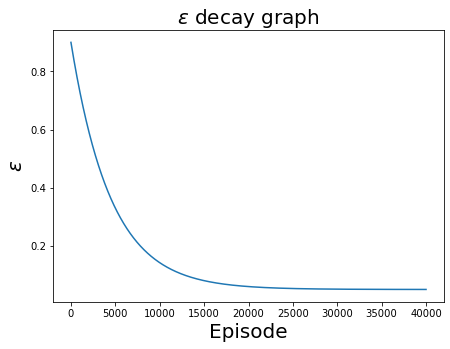

In [41]:
# device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
# Assuming that we are on a CUDA machine, this should print a CUDA device:
# print(device)
import matplotlib.pyplot as plt
import numpy as np
# epilson decay graph
EPS_START = 0.9
EPS_END = 0.05
EPS_DECAY = 4500

steps_done = np.arange(40000)
eps = EPS_END + (EPS_START - EPS_END) * np.exp(-1 * steps_done / EPS_DECAY)
plt.close()
fig, ax = plt.subplots(figsize=(7, 5))
ax.set_facecolor('white')
ax.plot(steps_done, eps)
ax.set_title('$\epsilon$ decay graph', fontsize=20)
ax.set_xlabel('Episode', fontsize=20)
ax.set_ylabel('$\epsilon$', fontsize=20)

fig.savefig('epsilon_decay.png',
    facecolor='white',
    edgecolor='white',
    transparent=False)

In [23]:
import torch.optim as optim
import math

BATCH_SIZE = 128
GAMMA = 0.999

# get max no. of actions from action space
n_actions = board.width

height = board.height
width = board.width

policy_net = TransformerDQN().to(device)
# target_net will be updated every n episodes to tell policy_net a better estimate of how far off from convergence
target_net = TransformerDQN().to(device)
target_net.load_state_dict(policy_net.state_dict())
# set target_net in testing mode
target_net.eval()

optimizer = optim.Adam(policy_net.parameters())


In [45]:
def select_action(state, available_actions, steps_done=None, training=True, return_attn=False):

    state = torch.tensor(state, dtype=torch.long).to(device).unsqueeze(dim=0)

    epsilon = random.random()
    if training:
        eps_threshold = EPS_END + (EPS_START - EPS_END) * math.exp(-1 * steps_done / EPS_DECAY)
    else:
        eps_threshold = 0

    # follow epsilon-greedy policy
    if epsilon > eps_threshold:
        with torch.no_grad():
            # action recommendations from policy net
            if return_attn:
                logits, masked_logits, valid_action_mask, attn_maps = policy_net(state, return_attn=True)
                greedy_action = torch.argmax(masked_logits[0])
                return greedy_action.item(), attn_maps
            else:
                logits, masked_logits, valid_action_mask = policy_net(state) # (B,M), (B,M), (B,M)
                greedy_action = torch.argmax(masked_logits[0])
                return greedy_action.item()

    else:
        return random.choice(available_actions)

In [25]:
# random agent
def random_agent(actions):
    return random.choice(actions)

# win rate test
def win_rate_test():
    win_moves_taken_list = []
    win = []
    for i in range(100):
        board.reset()
        win_moves_taken = 0

        while not board.gameOver:
            state = board.board_state.copy()
            available_actions = board.get_allowed_moves()
            action = select_action(state, available_actions, training=False)
            state, reward = board.make_move(action, 1)
            win_moves_taken += 1

            if reward == 1:
                win_moves_taken_list.append(win_moves_taken)
                win.append(1)
                break

            available_actions = board.get_allowed_moves()
            action = random_agent(available_actions)
            state, reward = board.make_move(action, 2)

    return sum(win)/100, sum(win_moves_taken_list)/len(win_moves_taken_list)

In [26]:
import time 

def optimise_model():
    if len(replay_buffer) < BATCH_SIZE:
        return
    
    start_time = time.time()
    # print(f"optimising")
    
    transitions = replay_buffer.sample(BATCH_SIZE)

    # first get all the states, actions, rewards, next_states in the batch of transitions
    state_batch = []
    action_batch = []
    reward_batch = [] 
    not_final_next_state_batch = []
    not_final_state_mask = []

    for tran in transitions:
        state_batch.append(tran.state)
        action_batch.append([tran.action])
        reward_batch.append(tran.reward)
        if tran.next_state is not None:
            not_final_next_state_batch.append(tran.next_state)
            not_final_state_mask.append(True)
        else:
            not_final_state_mask.append(False)

    state_batch = torch.tensor(np.array(state_batch), dtype=torch.long, device=device)
    action_batch = torch.tensor(np.array(action_batch), dtype=torch.long, device=device)
    reward_batch = torch.tensor(np.array(reward_batch), dtype=torch.float, device=device)
    not_final_next_state_batch = torch.tensor(np.array(not_final_next_state_batch), dtype=torch.long, device=device)
    not_final_state_mask = torch.tensor(not_final_state_mask, device=device)

    time1 = time.time()
    # print(f"preprocessing time: {time1 - start_time:.4f} seconds")

    # prediction from policy_net
    logits, masked_logits, valid_action_mask = policy_net(state_batch)
    # get the logit corresponding to the action taken in the transition for each state in the batch
    state_action_values = masked_logits.gather(1, action_batch)
    
    # truth from target_net, initialize with zeros since terminal state value = 0
    next_state_values = torch.zeros(BATCH_SIZE, device=device)
    # tensor.detach() creates a tensor that shares storage with tensor that does not require grad
    target_logits, target_masked_logits, target_valid_action_mask = target_net(not_final_next_state_batch)
    next_state_values[not_final_state_mask] = target_masked_logits.max(1)[0].detach()
    # compute the expected Q values
    expected_state_action_values = (next_state_values * GAMMA) + reward_batch

    # Compute Huber loss
    loss = F.smooth_l1_loss(state_action_values, expected_state_action_values.unsqueeze(1)) # torch.tensor.unsqueeze returns a copy

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()    

    time2 = time.time()
    # print(f"optimisation time: {time2 - time1:.4f} seconds")


In [27]:
# avoid resetting
steps_done = 0
training_history = []

In [78]:
from itertools import count
from tqdm import tqdm

num_episodes = 80
# control how lagged is target network by updating every n episodes
TARGET_UPDATE = 10

for i in range(num_episodes): 
    print(i)

    # record every 20 epochs
    if i % 10 == 9:
        print(f"Testing at episode {i}...")
        win_rate, moves_taken = win_rate_test()
        training_history.append([i + 1, win_rate, moves_taken])
        th = np.array(training_history)
        # print training message every 200 epochs
        if i % 200 == 199:
            print('Episode {}: | win_rate: {} | moves_taken: {}'.format(i, th[-1, 1], th[-1, 2]))
    
    board.reset()
    state_p1 = board.board_state.copy()


    # print(f"\n\n==================== Starting a game ====================")
    # print(f"==================== Starting a game ====================")
    # print(f"==================== Starting a game ====================\n\n")

    game_txt = ""

    for t in count():
        available_actions = board.get_allowed_moves()

        # print(f"Player 1 moving:")
        action_p1 = select_action(state_p1, available_actions, steps_done)
        steps_done += 1
        state_p1_, reward_p1 = board.make_move(action_p1, 1)
        # board.render()    
        game_txt += f"Player 1 action: {action_p1}, reward: {reward_p1}\n"
        game_txt += f"{board.board_state.__str__()}\n"

        if board.gameOver:
            if reward_p1 == 1:
                # reward p1 for p1's win
                replay_buffer.add(Transition(state = state_p1, action = action_p1, reward = 1, next_state = None, done = True))
            else:
                # state action value tuple for a draw
                replay_buffer.add(Transition(state = state_p1, action = action_p1, reward = 0.5, next_state = None, done = True))
            break
        
        # print(f"Player 2 moving:")
        available_actions = board.get_allowed_moves()
        action_p2 = random_agent(available_actions)
        state_p2_, reward_p2 = board.make_move(action_p2, 2)
        # board.render()
        game_txt += f"Player 2 action: {action_p2}, reward: {reward_p2}\n"
        game_txt += f"{board.board_state.__str__()}\n"

        if board.gameOver:
            if reward_p2 == 1:
                # punish p1 for (random agent) p2's win 
                replay_buffer.add(Transition(state = state_p1, action = action_p1, reward = -1, next_state = None, done = True))
            else:
                # state action value tuple for a draw
                replay_buffer.add(Transition(state = state_p1, action = action_p1, reward = 0.5, next_state = None, done = True))
            break
        
        # punish for taking too long to win
        replay_buffer.add(Transition(state = state_p1, action = action_p1, reward = -0.05, next_state = state_p2_, done = False))
        state_p1 = state_p2_
        
        # Perform one step of the optimization (on the policy network)
        # optimise_model()

    # save game_txt 
    with open(f'games/game_{i}.txt', 'w') as f:
        f.write(game_txt)
    # np.savetxt(f'games/game_{i}.txt', game_txt, fmt='%s')
        
    # update the target network, copying all weights and biases in DQN
    if i % TARGET_UPDATE == TARGET_UPDATE - 1:
        target_net.load_state_dict(policy_net.state_dict())

print('Complete')

0
1
2
3
4
5
6
7
8
9
Testing at episode 9...
10
11
12
13
14
15
16
17
18
19
Testing at episode 19...
20
21
22
23
24
25
26
27
28
29
Testing at episode 29...
30
31
32
33
34
35
36
37
38
39
Testing at episode 39...
40
41
42
43
44
45
46
47
48
49
Testing at episode 49...
50
51
52
53
54
55
56
57
58
59
Testing at episode 59...
60
61
62
63
64
65
66
67
68
69
Testing at episode 69...
70
71
72
73
74
75
76
77
78
79
Testing at episode 79...
Complete


In [204]:
win_rate, moves_taken = win_rate_test()

In [206]:
win_rate

0.95

IndexError: too many indices for array: array is 1-dimensional, but 2 were indexed

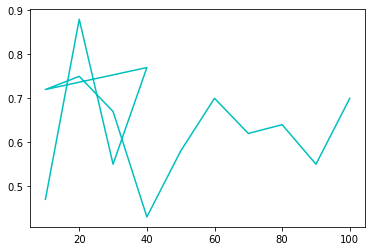

In [28]:
plt.plot(th[:, 0], th[:, 1], c='c')
win_rate_moving_average = np.array([[(i + 19) * 20, np.mean(th[i: i + 20, 1])] for i in range(len(th) - 19)])
plt.plot(win_rate_moving_average[:, 0], win_rate_moving_average[:, 1], c='b', label='moving average of win rate')
plt.legend()
plt.title('Playing against random agent')
plt.xlabel('Episode no.')
plt.ylabel('Win rate')
plt.show()

plt.plot(th[:, 0], th[:, 2], c='c')
win_steps_taken_moving_average = np.array([[(i + 19) * 20, np.mean(th[i: i + 20, 2])] for i in range(len(th) - 19)])
plt.plot(win_steps_taken_moving_average[:, 0], win_steps_taken_moving_average[:, 1], c='b', label='moving average of win steps taken')
plt.legend()
plt.xlabel('Episode no.')
plt.ylabel('Average steps taken for a win')
plt.show()

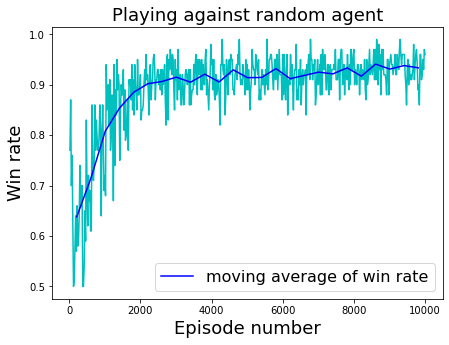

In [32]:
th = np.load("training_history.npy")

win_rate_moving_average = [np.mean(th[i: i+20, 1]) for i in range(0, len(th), 20)]
mid_points = [(th[i,0] + th[i+19,0]) / 2 for i in range(0, len(th), 20)]

fig, ax = plt.subplots(figsize=(7, 5))
ax.set_title('Playing against random agent', fontsize=18)
ax.set_xlabel('Episode number', fontsize=18)
ax.set_ylabel('Win rate', fontsize=18)

ax.plot(th[:, 0], th[:, 1], c='c')
ax.plot(mid_points, win_rate_moving_average, c='b', label='moving average of win rate')
plt.legend(fontsize=16)
plt.savefig('win_rate_and_steps.png',
    facecolor='white',
    edgecolor='white',
    transparent=False)

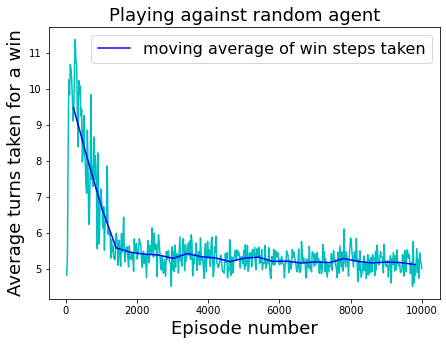

In [33]:
win_steps_moving_average = [np.mean(th[i: i+20, 2]) for i in range(0, len(th), 20)]
mid_points = [(th[i,0] + th[i+19,0]) / 2 for i in range(0, len(th), 20)]

fig, ax = plt.subplots(figsize=(7, 5))
ax.set_title('Playing against random agent', fontsize=18)
ax.set_xlabel('Episode number', fontsize=18)
ax.set_ylabel('Average turns taken for a win', fontsize=18)

ax.plot(th[:, 0], th[:, 2], c='c')
ax.plot(mid_points, win_steps_moving_average, c='b', label='moving average of win steps taken')
plt.legend(fontsize=16)
plt.savefig('number_of_steps.png',
    facecolor='white',
    edgecolor='white',
    transparent=False)

In [33]:
policy_net.state_dict()

policy_net.load_state_dict(torch.load("DQN_model_newReward.pth", map_location=torch.device('cpu')))

<All keys matched successfully>

In [4]:
# def renderBoard(board_state):
#     board_state = board_state.copy()[::-1]
#     plt.close()

#     # want to draw the board. Start with 1x1 blue squares at each cell
#     fig, ax = plt.subplots(figsize=(7,6))
#     plt.xlim(0, 7)
#     plt.ylim(0, 6)
#     # remove the ticks
#     plt.xticks([])
#     plt.yticks([])

#     for r in range(6):
#         for c in range(7):
#             cell = plt.Rectangle((c, r), 1, 1, facecolor='blue', edgecolor='blue')
#             ax.add_patch(cell)


#     # now add white cicles that are the holes 
#     for r in range(6):
#         for c in range(7):
#             hole = plt.Circle((c + 0.5, r + 0.5), 0.45, facecolor='white', edgecolor='black')
#             ax.add_patch(hole)

#     colors = {1 : 'red', 2 : 'yellow'}
#     # now add red circles for player 1 pieces and yellow circles for player 2 pieces
#     for r in range(6):
#         for c in range(7):
#             if board_state[r, c] != 0:
#                 piece = plt.Circle((c + 0.5, r + 0.5), 0.45, facecolor=colors[board_state[r, c]], edgecolor='black')
#                 ax.add_patch(piece)
#     plt.show()

import matplotlib.pyplot as plt
import numpy as np

def renderBoard(board_state, ax=None):
    board_state = board_state.copy()[::-1]

    # If no axis is provided, create one
    if ax is None:
        fig, ax = plt.subplots(figsize=(7, 6))
    else:
        fig = ax.figure

    ax.set_xlim(0, 7)
    ax.set_ylim(0, 6)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_aspect('equal')

    # Draw blue board
    for r in range(6):
        for c in range(7):
            cell = plt.Rectangle((c, r), 1, 1,
                                 facecolor='blue',
                                 edgecolor='blue')
            ax.add_patch(cell)

    # Draw white holes
    for r in range(6):
        for c in range(7):
            hole = plt.Circle((c + 0.5, r + 0.5),
                              0.45,
                              facecolor='white',
                              edgecolor='black')
            ax.add_patch(hole)

    colors = {1: 'red', 2: 'yellow'}

    # Draw pieces
    for r in range(6):
        for c in range(7):
            if board_state[r, c] != 0:
                piece = plt.Circle((c + 0.5, r + 0.5),
                                   0.45,
                                   facecolor=colors[board_state[r, c]],
                                   edgecolor='black')
                ax.add_patch(piece)

    return fig, ax

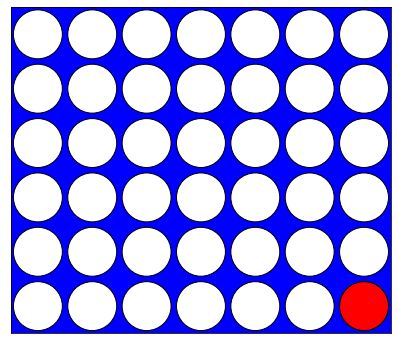

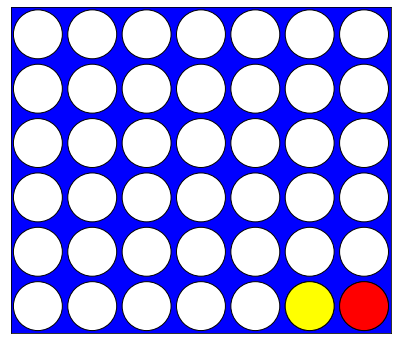

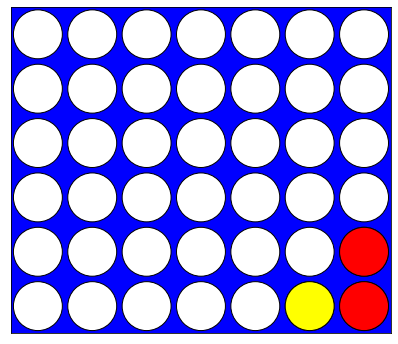

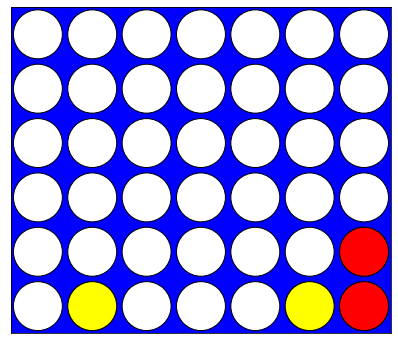

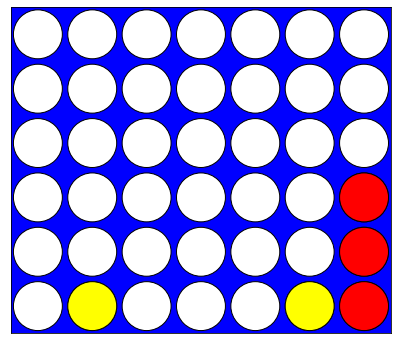

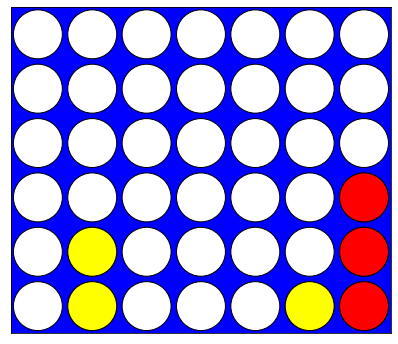

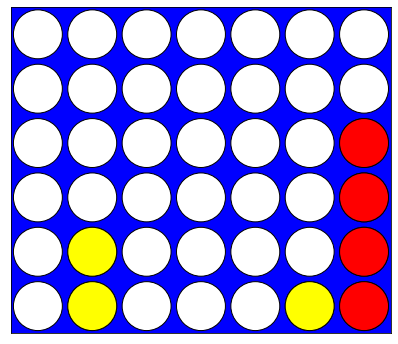

In [43]:
def demo():
    board.reset()
    # board.render()

    while not board.gameOver:
        state = board.board_state.copy()
        available_actions = board.get_allowed_moves()
        action = select_action(state, available_actions, training=False)
        # trained agent's move is denoted by O
        state, reward = board.make_move(action, 1)
        # board.render()
        renderBoard(state)

        if reward == 1:
            break

        available_actions = board.get_allowed_moves()
        action = random_agent(available_actions)
        state, reward = board.make_move(action, 2)
        # board.render()
        renderBoard(state)

demo()

In [38]:
def demoGame():
    board.reset()
    # board.render()

    states = []

    while not board.gameOver:
        state = board.board_state.copy()
        available_actions = board.get_allowed_moves()
        action = select_action(state, available_actions, training=False)
        # trained agent's move is denoted by O
        state, reward = board.make_move(action, 1)
        # board.render()
        states.append(state)

        if reward == 1:
            break

        available_actions = board.get_allowed_moves()
        action = random_agent(available_actions)
        state, reward = board.make_move(action, 2)
        # board.render()
        states.append(state)
    return states
states = demoGame()



/tmp/ipykernel_463593/3437118902.py:30: UserWarning: This figure was using constrained_layout, but that is incompatible with subplots_adjust and/or tight_layout; disabling constrained_layout.
  plt.tight_layout()


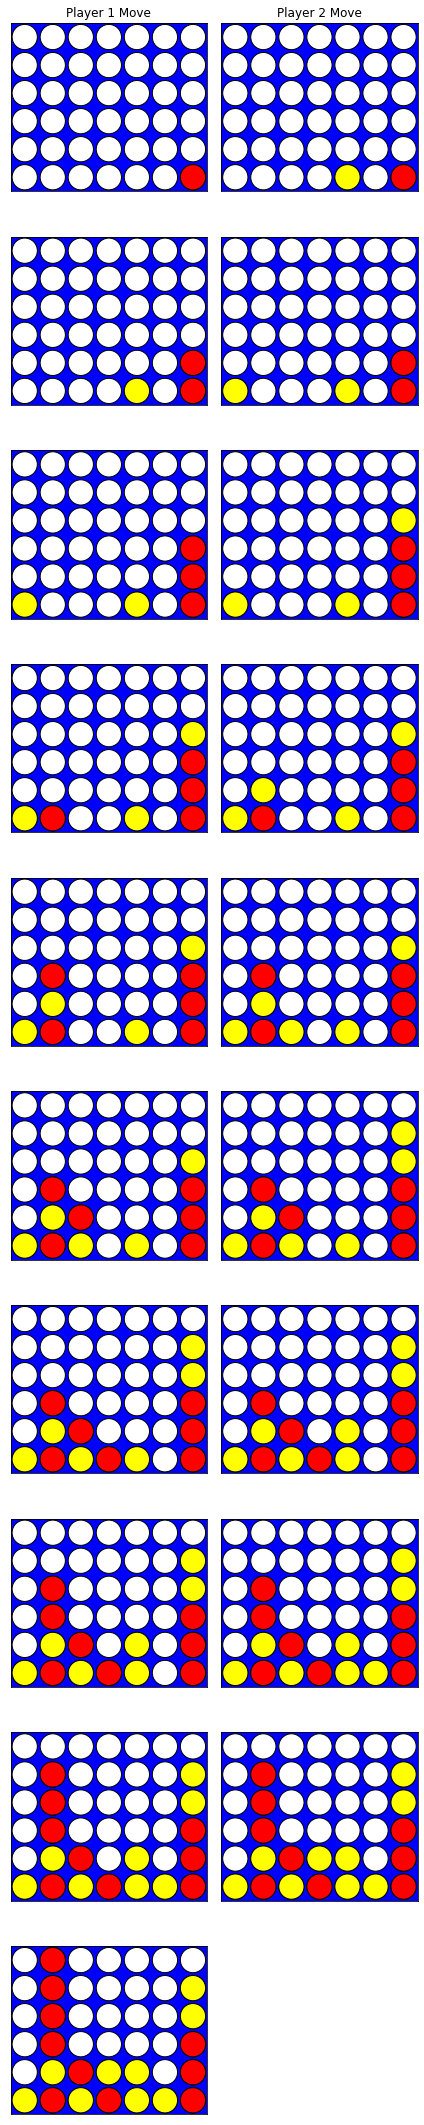

In [39]:
# plot of grid of 2 columns and N rows (depending on len(states))
num_states = len(states)
cols = 2
rows = (num_states + 1) // cols

n_plots = rows * cols

fig, axes = plt.subplots(rows, cols, figsize=(cols * 3, rows * 3), constrained_layout=True)

for i in range(n_plots):
    r = i // cols
    c = i % cols

    if i >= len(states):
        # delete this subplot
        axes[r, c].remove()
        # axes[r, c].set_xlim(0, 7)
        # axes[r, c].set_ylim(0, 6)
        # axes[r, c].set_xticks([])
        # axes[r, c].set_yticks([])
        continue

    state = states[i]
    ax = axes[r, c]

    renderBoard(state, ax=ax)

axes[0, 0].set_title(f"Player 1 Move")
axes[0, 1].set_title(f"Player 2 Move")
plt.tight_layout()
# minimise space between subplots
# plt.subplots_adjust(wspace=0.1, hspace=-0.6)
plt.show()

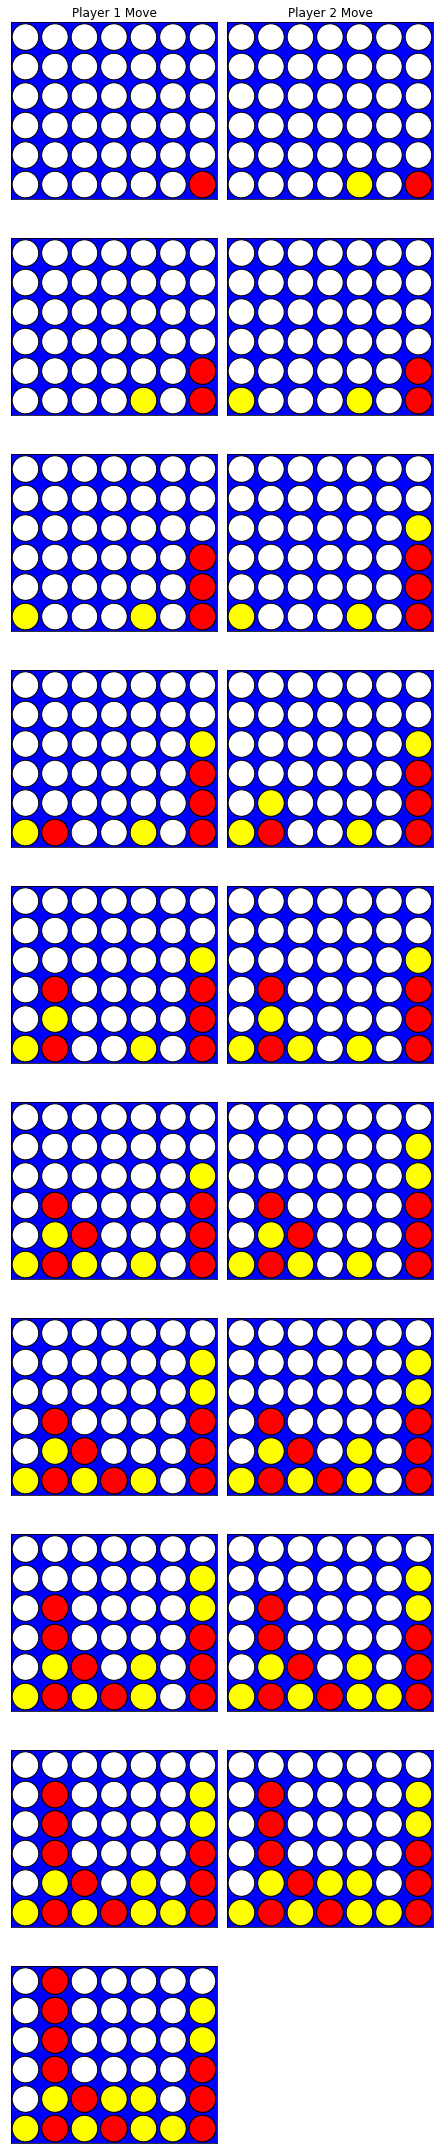

In [21]:
import matplotlib.pyplot as plt
# plot of grid of 2 columns and N rows (depending on len(states))
states = np.load('demo_game_states.npy')

num_states = len(states)
cols = 2
rows = (num_states + 1) // cols

n_plots = rows * cols

fig, axes = plt.subplots(rows, cols, figsize=(cols * 3, rows * 3), constrained_layout=True)

for i in range(n_plots):
    r = i // cols
    c = i % cols

    if i >= len(states):
        # delete this subplot
        axes[r, c].remove()
        # axes[r, c].set_xlim(0, 7)
        # axes[r, c].set_ylim(0, 6)
        # axes[r, c].set_xticks([])
        # axes[r, c].set_yticks([])
        continue

    state = states[i]
    ax = axes[r, c]

    renderBoard(state, ax=ax)

axes[0, 0].set_title(f"Player 1 Move")
axes[0, 1].set_title(f"Player 2 Move")
# plt.tight_layout()
# minimise space between subplots
# plt.subplots_adjust(wspace=0.1, hspace=-0.6)
# reduce vertical space between plots 
# plt.subplots_adjust(top=0.5, right=1)
plt.savefig("demo_game_states.png", dpi=300, bbox_inches='tight',
                facecolor='white',
    edgecolor='white',
    transparent=False)
plt.show()

In [145]:
def demoGameWithAttentions():
    board.reset()
    # board.render()

    states = []
    attn_maps = []
    p1_moves = []

    while not board.gameOver:
        state = board.board_state.copy()
        available_actions = board.get_allowed_moves()
        action, attn_map = select_action(state, available_actions, training=False, return_attn=True)
        # trained agent's move is denoted by O
        state, reward = board.make_move(action, 1)
        # board.render()
        states.append(state)
        p1_moves.append(action)
        attn_maps.append(attn_map)

        if reward == 1:
            break

        available_actions = board.get_allowed_moves()
        action = random_agent(available_actions)
        state, reward = board.make_move(action, 2)
        # board.render()
        states.append(state)
    return states, attn_maps, p1_moves

states, attn_maps, p1_moves = demoGameWithAttentions()



In [184]:
states[2]

array([[0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 2],
       [0, 0, 1, 0, 0, 0, 1]], dtype=int8)

In [182]:
def convertLoc(loc):
    # e.g. loc = [0, 3] means row 0 column 3, which is the top cell of column 3, so convert to [2, 5] which is the cell that the piece will actually occupy
    # e.g. loc = [5, 3] means row 5 column 3, which is the bottom cell of column 3, so convert to [2, 0] which is the cell that the piece will actually occupy
    return [5 - loc[0], loc[1]]

p1_move_locs = []

for i, state in enumerate(states):
    if i == 0:
        # get location of 1 in the state array 
        loc = np.argwhere(state == 1)[0]
        p1_move_locs.append(convertLoc(loc))
    else:
        if i % 2 == 0:
            cur_state = state
            prev_state = states[i - 1]
            state_change = cur_state - prev_state
            loc = np.argwhere(state_change == 1)[0]
            p1_move_locs.append(convertLoc(loc))

In [183]:
p1_move_locs

[[0, 6], [0, 2], [1, 2], [2, 2], [3, 2]]

In [ ]:



turn = 3
move = p1_move_locs[turn]
# convert this to unravelled index between 1 and 42 (since 0 is CLS token index)
move_idx = move[0] * 7 + move[1] + 1
print(move_idx)

layer = 0

qi = move_idx  # 0 = CLS token index
b = 0

def idx_to_rc(idx, n_cols=7):
    # idx is in [1, N*M] for cells, where 0 is CLS
    cell = idx - 1
    r = cell // n_cols
    c = cell % n_cols
    return r, c


topks = []
for head in range(4):
    # we only save attn_maps for player 1 moves, e.g. turn 0, 2, 4, ... since only those have attentions from the policy net. So we can index attn_maps by turn number directly.
    state = states[turn * 2]
    attn = attn_maps[turn][layer][b, head]          # (S,S)
    weights = attn[qi]                         # (S,)
    topk = torch.topk(weights, k=5)
    topks.append(topk)


24


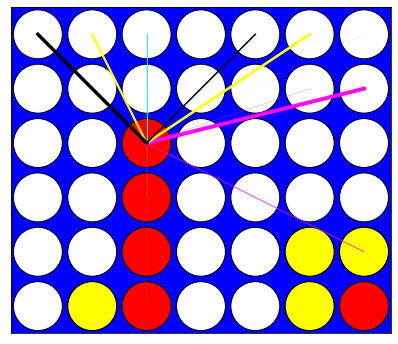

In [241]:



fig, ax = plt.subplots(figsize=(7, 6))

renderBoard(state, ax=ax)

colors = {0: 'cyan', 1: 'magenta', 2: 'yellow', 3: 'black'}

for head in range(4):
    topk = topks[head]
    # I want to overlay the top3 attention weights from the move that the model just made, to all other points on the board, not including the CLS token.
    for idx, weight in zip(topk.indices.cpu().numpy(), topk.values.cpu().numpy()):
        if idx == 0:
            continue  # skip CLS token
        r, c = idx_to_rc(idx)
        ax.plot([move[1]+0.5, c + 0.5], [move[0]+0.5, r + 0.5], c=colors[head], linewidth=weight * 5)

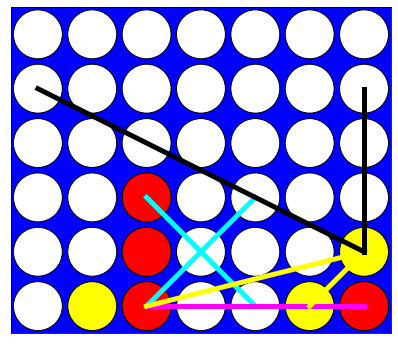

In [259]:
turn = 3
layer = 0
b = 0

state = states[turn * 2]

fig, ax = plt.subplots(figsize=(7, 6))

renderBoard(state, ax=ax)

# do the same as before, but find the top 5 attention weights over the whole board (not just the move location) and plot those as well, with a different color scheme
for head in range(4):
    attn = attn_maps[turn][layer][b, head]          # (S,S)
    # attn is shape (S, S) i.e. attention from each token to each token. I want to find the top 5 attention weights over the whole board (not just the move location) 
    # and the plot these. But for this I need the top values overall, and both the source and destination indices, so I will use torch.topk on the flattened attention map, and then convert the flattened indices back to 2D indices.
    attn_flat = attn.flatten()
    topk = torch.topk(attn_flat, k=2)

    for idx, weight in zip(topk.indices.cpu().numpy(), topk.values.cpu().numpy()):
        src_idx = idx // attn.shape[1]
        dst_idx = idx % attn.shape[1]

        if src_idx == 0 or dst_idx == 0:
            continue  # skip if either source or destination is CLS token

        src_r, src_c = idx_to_rc(src_idx)
        dst_r, dst_c = idx_to_rc(dst_idx)

        src_r, src_c = convertLoc((src_r, src_c))
        dst_r, dst_c = convertLoc((dst_r, dst_c))

        ax.plot([src_c + 0.5, dst_c + 0.5], [src_r + 0.5, dst_r + 0.5], c=colors[head], linewidth=weight * 5)

In [247]:
attn

tensor([[6.3186e-25, 9.8514e-16, 6.2718e-26,  ..., 3.6401e-03, 3.1238e-01,
         3.1959e-07],
        [8.0535e-03, 1.2505e-05, 3.3311e-04,  ..., 7.3131e-08, 2.1085e-07,
         4.0582e-07],
        [3.1265e-02, 2.3653e-02, 1.2696e-02,  ..., 1.7207e-02, 4.1445e-03,
         1.5293e-02],
        ...,
        [4.2598e-13, 5.3934e-10, 7.4713e-13,  ..., 3.2276e-02, 9.8018e-05,
         1.2586e-05],
        [3.2196e-07, 4.0540e-05, 2.0972e-06,  ..., 5.0724e-02, 4.9625e-05,
         1.7739e-04],
        [2.2494e-05, 3.8042e-03, 2.2043e-05,  ..., 1.2525e-01, 2.1884e-03,
         3.8076e-04]])

In [55]:
idx_to_rc(topk.indices[0].item())

(5, 4)

In [144]:
def optimise_model_new():
    if len(replay_buffer) < BATCH_SIZE:
        return
    
    print(f"optimising")
    
    transitions = replay_buffer.sample(BATCH_SIZE)

    # first get all the states, actions, rewards, next_states in the batch of transitions
    state_batch = []
    action_batch = []
    reward_batch = [] 
    not_final_next_state_batch = []
    not_final_state_mask = []

    for tran in transitions:
        state_batch.append(tran.state)
        action_batch.append([tran.action])
        reward_batch.append(tran.reward)
        if tran.next_state is not None:
            not_final_next_state_batch.append(tran.next_state)
            not_final_state_mask.append(True)
        else:
            not_final_state_mask.append(False)

    state_batch = torch.tensor(np.array(state_batch), dtype=torch.long, device=device)
    action_batch = torch.tensor(np.array(action_batch), dtype=torch.long, device=device)
    reward_batch = torch.tensor(np.array(reward_batch), dtype=torch.float, device=device)
    not_final_next_state_batch = torch.tensor(np.array(not_final_next_state_batch), dtype=torch.long, device=device)
    not_final_state_mask = torch.tensor(not_final_state_mask, device=device)

    # prediction from policy_net
    logits, masked_logits, valid_action_mask = policy_net(state_batch)
    # get the logit corresponding to the action taken in the transition for each state in the batch
    state_action_values = masked_logits.gather(1, action_batch)
    
    # truth from target_net, initialize with zeros since terminal state value = 0
    next_state_values = torch.zeros(BATCH_SIZE, device=device)
    # tensor.detach() creates a tensor that shares storage with tensor that does not require grad
    target_logits, target_masked_logits, target_valid_action_mask = target_net(not_final_next_state_batch)
    next_state_values[not_final_state_mask] = target_masked_logits.max(1)[0].detach()
    # compute the expected Q values
    expected_state_action_values = (next_state_values * GAMMA) + reward_batch

    # Compute Huber loss
    loss = F.smooth_l1_loss(state_action_values, expected_state_action_values.unsqueeze(1)) # torch.tensor.unsqueeze returns a copy

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()    


optimise_model_new()

optimising


In [ ]:
def optimise_model():
    if len(replay_buffer) < BATCH_SIZE:
        return
    
    transitions = replay_buffer.sample(BATCH_SIZE)
    state_batch, action_batch, player, reward_batch, next_state_batch = zip(*[(m[0], \
                                        [m[1]], m[2], m[3], m[4]) for m in transitions])
    # tensor wrapper
    state_batch = torch.tensor(state_batch, dtype=torch.long, device=device)
    action_batch = torch.tensor(action_batch, dtype=torch.long, device=device)
    player_batch = torch.tensor(player, dtype=torch.long, device=device)
    reward_batch = torch.tensor(reward_batch, dtype=torch.float, device=device)

    
    
    # for assigning terminal state value = 0 later
    non_final_mask = torch.tensor(tuple(map(lambda s_: s_[0] is not None, next_state_batch)), device=device) # e.g. [True, True, False, True, False]
    non_final_next_state = torch.cat([torch.tensor(s_, dtype=torch.long, device=device).unsqueeze(0) for s_ in next_state_batch if s_[0] is not None])
    
    # prediction from policy_net
    state_action_values = policy_net(state_batch, player_batch).gather(1, action_batch)
    
    # truth from target_net, initialize with zeros since terminal state value = 0
    next_state_values = torch.zeros(BATCH_SIZE, device=device)
    # tensor.detach() creates a tensor that shares storage with tensor that does not require grad
    next_state_values[non_final_mask] = target_net(non_final_next_state, player_batch).max(1)[0].detach()
    # compute the expected Q values
    expected_state_action_values = (next_state_values * GAMMA) + reward_batch

    # Compute Huber loss
    loss = F.smooth_l1_loss(state_action_values, expected_state_action_values.unsqueeze(1)) # torch.tensor.unsqueeze returns a copy

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()


optimise_model()

IndexError: index out of range in self

In [304]:
transitions = replay_buffer.sample(BATCH_SIZE)
state_batch, action_batch, reward_batch, next_state_batch = zip(*[(m[0], \
                                    [m[1]], m[2], m[3]) for m in transitions])
# tensor wrapper
state_batch = torch.tensor(state_batch, dtype=torch.float, device=device)
action_batch = torch.tensor(action_batch, dtype=torch.long, device=device)
reward_batch = torch.tensor(reward_batch, dtype=torch.float, device=device)

non_final_mask = torch.tensor(tuple(map(lambda s_: s_[0] is not None, next_state_batch)), device=device)

TypeError: 'NoneType' object is not subscriptable

In [305]:
transitions[0]

[array([[0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 2],
        [0, 0, 0, 0, 0, 0, 2],
        [1, 1, 2, 1, 0, 1, 2]], dtype=int8),
 1,
 -0.05,
 array([[0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0],
        [0, 2, 0, 0, 0, 0, 2],
        [0, 1, 0, 0, 0, 0, 2],
        [1, 1, 2, 1, 0, 1, 2]], dtype=int8)]

In [276]:
state_batch[0][0]

tensor([[0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 1., 2., 0., 0.],
        [2., 0., 0., 1., 2., 1., 0.],
        [1., 0., 1., 2., 1., 2., 2.]])

In [257]:
replay_buffer.memory[4]

[array([[0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0],
        [0, 2, 0, 0, 0, 0, 1],
        [0, 2, 0, 0, 0, 0, 1],
        [0, 2, 1, 0, 0, 2, 1]], dtype=int8),
 6,
 1,
 None]

In [241]:
torch.tensor(board.board_state.copy(), dtype=torch.long).to(device).unsqueeze(dim=0).shape

torch.Size([1, 6, 7])

In [236]:
board.board_state.copy()

array([[0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0],
       [0, 2, 0, 0, 0, 0, 0],
       [0, 1, 0, 0, 0, 0, 0],
       [2, 2, 1, 1, 2, 0, 1]], dtype=int8)

In [238]:
state_p1

array([[0, 0, 0, 0, 1, 0, 0],
       [0, 0, 0, 0, 2, 0, 0],
       [0, 0, 0, 0, 1, 0, 0],
       [0, 0, 0, 0, 1, 0, 0],
       [0, 0, 0, 2, 2, 0, 2],
       [0, 0, 0, 1, 2, 0, 1]], dtype=int8)

In [71]:
x = torch.zeros(6, 7).to(device).unsqueeze(dim=0).unsqueeze(dim=0)

print(policy_net(x)[0, :])
r_actions = policy_net(x)[0, :]

available_actions = board.get_allowed_moves()
print("Available actions:", available_actions)

state_action_values = [r_actions[action] for action in available_actions]

tensor([-0.0141,  0.1460, -0.1442,  0.1816,  0.0928, -0.0636,  0.1242],
       grad_fn=<SliceBackward0>)
Available actions: [0, 1, 2, 3, 4, 5, 6]


In [99]:
other_net = ConnectKTransformerPolicy(
        n_rows=6,
        n_cols=7,
        d_model=32,
        num_heads=8,
        num_layers=3,
        d_ff=128,
        dropout=0.1,
    )


x = torch.zeros(6, 7, dtype=torch.long).to(device).unsqueeze(dim=0)

print(x[0,:,0])

x[0,:,0] = torch.ones_like(x[0,:,0])

logits, masked_logits, valid_action_mask = other_net(x, torch.tensor([0], dtype=torch.long))

masked_logits

tensor([0, 0, 0, 0, 0, 0])


tensor([[-1.0000e+09, -8.1859e-01, -4.0086e-03, -1.2206e+00,  4.5181e-01,
          2.9782e-01, -6.7362e-01]], grad_fn=<MaskedFillBackward0>)

In [100]:
print(logits)
print(masked_logits)

tensor([[ 0.9620, -0.8186, -0.0040, -1.2206,  0.4518,  0.2978, -0.6736]],
       grad_fn=<AddmmBackward0>)
tensor([[-1.0000e+09, -8.1859e-01, -4.0086e-03, -1.2206e+00,  4.5181e-01,
          2.9782e-01, -6.7362e-01]], grad_fn=<MaskedFillBackward0>)


In [101]:
print(x)

tensor([[[1, 0, 0, 0, 0, 0, 0],
         [1, 0, 0, 0, 0, 0, 0],
         [1, 0, 0, 0, 0, 0, 0],
         [1, 0, 0, 0, 0, 0, 0],
         [1, 0, 0, 0, 0, 0, 0],
         [1, 0, 0, 0, 0, 0, 0]]])


In [ ]:
def optimize_model():
    if len(replay_buffer) < BATCH_SIZE:
        return
    transitions = replay_buffer.sample(BATCH_SIZE)
    state_batch, action_batch, reward_batch, next_state_batch = zip(*[(np.expand_dims(m[0], axis=0), \
                                        [m[1]], m[2], np.expand_dims(m[3], axis=0)) for m in transitions])
    # tensor wrapper
    state_batch = torch.tensor(state_batch, dtype=torch.float, device=device)
    action_batch = torch.tensor(action_batch, dtype=torch.long, device=device)
    reward_batch = torch.tensor(reward_batch, dtype=torch.float, device=device)
    
    # for assigning terminal state value = 0 later
    non_final_mask = torch.tensor(tuple(map(lambda s_: s_[0] is not None, next_state_batch)), device=device)
    non_final_next_state = torch.cat([torch.tensor(s_, dtype=torch.float, device=device).unsqueeze(0) for s_ in next_state_batch if s_[0] is not None])
    
    # prediction from policy_net
    state_action_values = policy_net(state_batch).gather(1, action_batch)
    
    # truth from target_net, initialize with zeros since terminal state value = 0
    next_state_values = torch.zeros(BATCH_SIZE, device=device)
    # tensor.detach() creates a tensor that shares storage with tensor that does not require grad
    next_state_values[non_final_mask] = target_net(non_final_next_state).max(1)[0].detach()
    # compute the expected Q values
    expected_state_action_values = (next_state_values * GAMMA) + reward_batch

    # Compute Huber loss
    loss = F.smooth_l1_loss(state_action_values, expected_state_action_values.unsqueeze(1)) # torch.tensor.unsqueeze returns a copy

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

In [54]:
# random agent
def random_agent(actions):
    return random.choice(actions)

# win rate test
def win_rate_test():
    win_moves_taken_list = []
    win = []
    for i in range(100):
        board.reset()
        win_moves_taken = 0

        while not board.isDone:
            state = board.board_state.copy()
            available_actions = board.get_available_actions()
            action = select_action(state, available_actions, training=False)
            state, reward = board.make_move(action, 'p1')
            win_moves_taken += 1

            if reward == 1:
                win_moves_taken_list.append(win_moves_taken)
                win.append(1)
                break

            available_actions = board.get_available_actions()
            action = random_agent(available_actions)
            state, reward = board.make_move(action, 'p2')

    return sum(win)/100, sum(win_moves_taken_list)/len(win_moves_taken_list)

In [55]:
# avoid resetting
steps_done = 0
training_history = []

In [ ]:
from itertools import count
from tqdm import tqdm

num_episodes = 200
# control how lagged is target network by updating every n episodes
TARGET_UPDATE = 10

for i in tqdm(range(num_episodes)): 
    board.reset()
    state_p1 = board.board_state.copy()

    # record every 20 epochs
    if i % 20 == 19:
        win_rate, moves_taken = win_rate_test()
        training_history.append([i + 1, win_rate, moves_taken])
        th = np.array(training_history)
        # print training message every 200 epochs
        if i % 200 == 199:
            print('Episode {}: | win_rate: {} | moves_taken: {}'.format(i, th[-1, 1], th[-1, 2]))

    for t in count():
        available_actions = board.get_available_actions()
        action_p1 = select_action(state_p1, available_actions, steps_done)
        steps_done += 1
        state_p1_, reward_p1 = board.make_move(action_p1, 'p1')
        
        if board.isDone:
            if reward_p1 == 1:
                # reward p1 for p1's win
                replay_buffer.dump([state_p1, action_p1, 1, None])
            else:
                # state action value tuple for a draw
                replay_buffer.dump([state_p1, action_p1, 0.5, None])
            break
        
        available_actions = board.get_available_actions()
        action_p2 = random_agent(available_actions)
        state_p2_, reward_p2 = board.make_move(action_p2, 'p2')
        
        if board.isDone:
            if reward_p2 == 1:
                # punish p1 for (random agent) p2's win 
                replay_buffer.dump([state_p1, action_p1, -1, None])
            else:
                # state action value tuple for a draw
                replay_buffer.dump([state_p1, action_p1, 0.5, None])
            break
        
        # punish for taking too long to win
        replay_buffer.dump([state_p1, action_p1, -0.05, state_p2_])
        state_p1 = state_p2_
        
        # Perform one step of the optimization (on the policy network)
        optimize_model()
        
    # update the target network, copying all weights and biases in DQN
    if i % TARGET_UPDATE == TARGET_UPDATE - 1:
        target_net.load_state_dict(policy_net.state_dict())

print('Complete')

In [15]:
board_height = 6
board_width = 7
board_state = np.zeros([board_height, board_width], dtype=np.int8)

board_state

array([[0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0]], dtype=int8)

In [41]:
board_state[-1, 0] = 1
board_state[-2, 0] = 1
board_state[-3, 0] = 1
board_state[-4, 0] = 0
board_state[-5, 0] = 0
board_state[-6, 0] = 0

board_state[-2, 1] = 1
board_state[-3, 2] = 1
board_state[-4, 3] = 1

board_state[-1, 3] = 3
board_state[-2, 3] = 3
board_state[-3, 3] = 3
# board_state[-4, 3] = 2
# board_state[-5, 3] = 2

board_state

array([[0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 1, 0, 0, 0],
       [1, 0, 1, 3, 0, 0, 0],
       [1, 1, 0, 3, 0, 0, 0],
       [1, 0, 0, 3, 0, 0, 0]], dtype=int8)

In [17]:
col = board_state[:,3]
# find first occurance of 0 
open_slot_from_bottom = np.argmax(col[::-1] == 0)
open_slot = len(col) - 1 - open_slot_from_bottom
open_slot

1

In [18]:
col = board_state[:,3]
# find last occurance of 0
open_slot_from_top = np.argmax(col != 0) - 1
open_slot_from_top

1

In [19]:
def checkHas4InARow(arr, player):
    player_arr = np.array([player]*4)
    for i in range(len(arr) - 3):
        if np.array_equal(arr[i:i+4], player_arr): 
            return True
    
    return False


col = board_state[:,0]
print(col)
# check if 4 consecutive 1s or 2s
if checkHas4InARow(col, 1):
    print('4 in a row for player 1')
elif checkHas4InARow(col, 2):
    print('4 in a row for player 2')

# with the board, I need to check right diagonal and left diagonal as well, which is a bit more complicated but can be done with some indexing
# check right diagonal
for k in range(0, board_height - 4 + 1):
    for j in range(0, board_width - 4 + 1):
        right_diagonal = np.array([board_state[k + d, j + d] for d in range(4)]) # range(min(board_height - k, board_width - j))])
        print(k, j, right_diagonal)
        if checkHas4InARow(right_diagonal, 1):
            print('4 in a row for player 1')
        elif checkHas4InARow(right_diagonal, 2):
            print('4 in a row for player 2')

# for k in range(0, board_height - 4 + 1):
#     right_diagonal = np.array([board_state[k + d, d] for d in range(min(board_height - k, min(board_height, board_width)))])
#     print(right_diagonal)
#     for i in range(len(right_diagonal) - 3):
#         if checkHas4InARow(right_diagonal[i:i+4], 1):
#             print('4 in a row for player 1')
#         elif checkHas4InARow(right_diagonal[i:i+4], 2):
#             print('4 in a row for player 2')

[0 0 1 1 1 1]
4 in a row for player 1
0 0 [0 0 0 3]
0 1 [0 0 2 0]
0 2 [0 0 0 0]
0 3 [0 0 0 0]
1 0 [0 0 0 3]
1 1 [0 0 3 0]
1 2 [0 2 0 0]
1 3 [0 0 0 0]
2 0 [1 0 0 3]
2 1 [0 0 3 0]
2 2 [0 3 0 0]
2 3 [2 0 0 0]


In [20]:
def checkHas4InARow(arr, player):
    player_arr = np.array([player]*4)
    for i in range(len(arr) - 3):
        if np.array_equal(arr[i:i+4], player_arr): 
            return True
    
    return False

In [43]:
def checkHas4InARowNew(arr, player):

    current_val = arr[0]
    current_count = 1

    longest_val = arr[0]
    longest_count = 1

    for val in arr[1:]:
        if val == current_val:
            current_count += 1
        else:
            current_val = val
            current_count = 1
        
        if current_count > longest_count:
            longest_count = current_count
            longest_val = current_val

    if (longest_val == player) and (longest_count >= 4):
        return True

    return False


col = board_state[:,0]
print(col)


# check if 4 consecutive 1s or 2s
for i in range(board_width):
    col = board_state[:,i]
    has4 = checkHas4InARowNew(col, 1)
    print(f'Has 4 in a row: {has4}')

# now check the diagonals
# Start with right diagonals, so start from the bottom left corner and move up to the right 
# The starting points are given by the x's shown below:
#   - - - - - - -
#   - - - - - - -
#   - - - - - - -
#   x x x - - - -
#   x x x - - - -
#   x x x - - - -

for col_idx in range(0, 4):
    for row_idx in range(3, 6):
        right_diagonal = [board_state[row_idx - d, col_idx + d] for d in range(4)]
        print(f'Right diagonal starting at ({row_idx}, {col_idx}), right diagonal: {right_diagonal}')
        has4 = checkHas4InARowNew(right_diagonal, 1)
        print(f'Right diagonal starting at ({row_idx}, {col_idx}), has 4 in a row: {has4}')

# Now do left diagonals
# The starting points are given by the x's shown below:
#   - - - - - - -
#   - - - - - - -
#   - - - - - - -
#   - - - - x x x
#   - - - - x x x
#   - - - - x x x

for col_idx in range(3, 7):
    for row_idx in range(3, 6):
        left_diagonal = [board_state[row_idx - d, col_idx - d] for d in range(4)]
        print(f'Left diagonal starting at ({row_idx}, {col_idx}), left diagonal: {left_diagonal}')
        has4 = checkHas4InARowNew(left_diagonal, 1)
        print(f'Left diagonal starting at ({row_idx}, {col_idx}), has 4 in a row: {has4}')

[0 0 0 1 1 1]
Has 4 in a row: False
Has 4 in a row: False
Has 4 in a row: False
Has 4 in a row: False
Has 4 in a row: False
Has 4 in a row: False
Has 4 in a row: False
Right diagonal starting at (3, 0), right diagonal: [1, 0, 0, 0]
Right diagonal starting at (3, 0), has 4 in a row: False
Right diagonal starting at (4, 0), right diagonal: [1, 0, 0, 0]
Right diagonal starting at (4, 0), has 4 in a row: False
Right diagonal starting at (5, 0), right diagonal: [1, 1, 1, 1]
Right diagonal starting at (5, 0), has 4 in a row: True
Right diagonal starting at (3, 1), right diagonal: [0, 0, 0, 0]
Right diagonal starting at (3, 1), has 4 in a row: False
Right diagonal starting at (4, 1), right diagonal: [1, 1, 1, 0]
Right diagonal starting at (4, 1), has 4 in a row: False
Right diagonal starting at (5, 1), right diagonal: [0, 0, 3, 0]
Right diagonal starting at (5, 1), has 4 in a row: False
Right diagonal starting at (3, 2), right diagonal: [1, 1, 0, 0]
Right diagonal starting at (3, 2), has 4 in

In [46]:
%%timeit 

for i in range(board_width):
    col = board_state[:,i]
    has4 = checkHas4InARowNew(col, 1)
    # print(f'Has 4 in a row: {has4}')

# now check the diagonals
# Start with right diagonals, so start from the bottom left corner and move up to the right 
# The starting points are given by the x's shown below:
#   - - - - - - -
#   - - - - - - -
#   - - - - - - -
#   x x x - - - -
#   x x x - - - -
#   x x x - - - -

for col_idx in range(0, 4):
    for row_idx in range(3, 6):
        right_diagonal = [board_state[row_idx - d, col_idx + d] for d in range(4)]
        # print(f'Right diagonal starting at ({row_idx}, {col_idx}), right diagonal: {right_diagonal}')
        has4 = checkHas4InARowNew(right_diagonal, 1)
        # print(f'Right diagonal starting at ({row_idx}, {col_idx}), has 4 in a row: {has4}')

# Now do left diagonals
# The starting points are given by the x's shown below:
#   - - - - - - -
#   - - - - - - -
#   - - - - - - -
#   - - - - x x x
#   - - - - x x x
#   - - - - x x x

for col_idx in range(3, 7):
    for row_idx in range(3, 6):
        left_diagonal = [board_state[row_idx - d, col_idx - d] for d in range(4)]
        # print(f'Left diagonal starting at ({row_idx}, {col_idx}), left diagonal: {left_diagonal}')
        has4 = checkHas4InARowNew(left_diagonal, 1)
        # print(f'Left diagonal starting at ({row_idx}, {col_idx}), has 4 in a row: {has4}')

92.9 µs ± 2.7 µs per loop (mean ± std. dev. of 7 runs, 10,000 loops each)


In [22]:
arr = [0, 0, 1, 1, 1, 2, 2, 1]

print(checkHas4InARowNew(arr))

(1, False)


In [23]:
%%timeit 

checkHas4InARow(arr, 1)

20.9 µs ± 450 ns per loop (mean ± std. dev. of 7 runs, 100,000 loops each)


In [24]:
%%timeit 

checkHas4InARowNew(arr)

611 ns ± 59.9 ns per loop (mean ± std. dev. of 7 runs, 1,000,000 loops each)


In [25]:
orig = 10.9 * 1e-6
new = 611 * 1e-9

print(f'Original: {orig:.2e} seconds, New: {new:.2e} seconds, Speedup: {orig/new:.2f}x')

Original: 1.09e-05 seconds, New: 6.11e-07 seconds, Speedup: 17.84x


In [ ]:
# 20.9 µs / # 20.9 µs =

In [45]:
np.array_equal

<function numpy.array_equal(a1, a2, equal_nan=False)>

In [27]:
board_state[:,0]

array([2, 2, 2, 1, 1, 1], dtype=int8)

In [28]:
for j in range(board_width):
    col = board_state[:, j]
    print(col)
    if 0 in col:
        print('available')

[2 2 2 1 1 1]
[0 0 0 0 0 0]
available
[0 0 0 0 0 0]
available
[0 2 2 3 3 3]
available
[0 0 0 0 0 0]
available
[0 0 0 0 0 0]
available
[0 0 0 0 0 0]
available


In [16]:
def get_available_actions(board_state, board_width):
    available_cols = []
    for j in range(board_width):
        if np.sum([board_state[:, j] == 0]) != 0:
            available_cols.append(j)
    return available_cols

get_available_actions(board_state, board_width)

[0, 1, 2, 3, 4, 5, 6]